# Import Libraries

In [ ]:
pip install rdkit mlflow

In [2]:
from google.colab import drive
import os
import numpy as np
import pandas as pd
import shap
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
from mlflow.tracking import MlflowClient
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors
import joblib
import matplotlib.pyplot as plt
import base64
from io import BytesIO
from IPython.display import display, HTML
import seaborn as sns

# Load Models

In [3]:
# load data
drive.mount('/content/drive')

# set working directory
os.chdir('/content/drive/MyDrive/Solubility')

Mounted at /content/drive


In [4]:
# load models
model = joblib.load("solubility_rf_model.joblib")
explainer = joblib.load("explainer_updated.pkl")

# Define Functions for Example Processing

In [5]:
# function to compute molecular descriptors for input molecule
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        st.error("Invalid SMILES string")
        return None

    descriptor_names = [
        "MaxEStateIndex",
        "MinEStateIndex",
        "qed",
        "SPS",
        "MolWt",
        "MaxPartialCharge",
        "MinPartialCharge",
        "FpDensityMorgan2",
        "BCUT2D_MWHI",
        "BCUT2D_CHGHI",
        "BCUT2D_LOGPHI",
        "BCUT2D_MRHI",
        "AvgIpc",
        "BalabanJ",
        "HallKierAlpha",
        "Ipc",
        "Kappa3",
        "TPSA",
        "FractionCSP3",
        "NumAromaticCarbocycles",
        "NumAromaticRings",
        "NumHAcceptors",
        "NumHDonors",
        "NumHeteroatoms",
        "NumRotatableBonds",
        "Phi",
        "RingCount",
        "MolLogP",
    ]

    descriptor_vals = {name: func(mol) for name, func in Descriptors.descList if name in descriptor_names}

    return pd.DataFrame([descriptor_vals])

In [32]:
# define function to get prediction for example molecule and map to solubility categories
def get_prediction(descriptors_df):

  # define target class mapping
  solubility_class_labels = {
    0: "Insoluble",
    1: "Slightly soluble",
    2: "Soluble",
  }

  # get prediction class
  predicted_class = model.predict(descriptors_df)[0]
  predicted_label = solubility_class_labels[predicted_class]

  # get class probs
  predicted_probs = model.predict_proba(descriptors_df)[0]
  probs_df = pd.DataFrame(
      data=[predicted_probs],
      columns=list(solubility_class_labels.values())
  )
  return predicted_class, predicted_label, probs_df

In [48]:
def get_shap_influence_scores(descriptors_df, descriptor_labels, top_k=5):

    # get all SHAP values for sample
    shap_values = explainer.shap_values(descriptors_df) # shape: (1, n_features, n_classes)

    # define centered ordinal weights instead of [0, 1, 2]
    ordinal_weights = np.array([-1, 0, 1])

    # get SHAP matrix for single sample
    shap_matrix = shap_values[0] # shape: (n_features, n_classes))

    # compute influence scores from dot product of SHAP matrix and ordinal weights
    influence_scores = np.dot(shap_matrix, ordinal_weights)

    # create SHAP dataframe
    shap_df = pd.DataFrame({
        "Feature": descriptors_df.columns,
        "Influence": influence_scores,
        "Feature Value": descriptors_df.iloc[0].values
    })

    # map feature names to interpretable labels
    shap_df["Feature"] = shap_df["Feature"].map(descriptor_labels).fillna(shap_df["Feature"])

    # determine contribution direction
    shap_df["Contribution"] = shap_df["Influence"].apply(
        lambda x: "Favors higher solubility class" if x > 0 else "Favors lower solubility class"
    )

    # sort by absolute influence for plot and select top_k features
    shap_df["Abs Influence"] = shap_df["Influence"].abs()
    shap_df = shap_df.sort_values(by="Abs Influence", ascending=False).head(top_k)

    return shap_df

In [62]:
def generate_html_report(smiles, top_k=5):

    # compute descriptors for input molecule
    descriptors_df = compute_descriptors(smiles)
    if descriptors_df is None:
        return "<p>Invalid SMILES string. Please try again.</p>"

    # map descriptors to interpretable names
    descriptor_labels = {
      "MolWt": "Molecular Weight",
      "MolLogP": "LogP",
      "TPSA": "Topological Polar Surface Area",
      "qed": "QED (Drug-likeness)",
      "FractionCSP3": "Fraction sp3 Carbons",
      "NumHAcceptors": "H-Bond Acceptor Count",
      "NumHDonors": "H-Bond Donor Count",
      "RingCount": "Ring Count",
      "FpDensityMorgan2": "Fragment Density",
      "BalabanJ": "Molecular Complexity (BalabanJ)",
      "MaxEStateIndex": "Max E-State Index",
      "MinEStateIndex": "Min E-State Index",
      "Phi": "Phi (Flexibility)",
      "SPS": "Simple Polar Surface"
    }

    # get molecule structure
    mol = Chem.MolFromSmiles(smiles)
    img = Draw.MolToImage(mol, size=(300, 300))
    buf = BytesIO()
    img.save(buf, format="PNG")
    img_data = base64.b64encode(buf.getvalue()).decode()
    img_html = f'<img src="data:image/png;base64,{img_data}" alt="Molecule Structure" style="max-width: 300px;">'

    # get predictions and probabilities
    predicted_class, predicted_label, prob_df = get_prediction(descriptors_df)
    prob_html = prob_df.to_html(index=False, float_format="%.2f")

    # get SHAP and influence scores
    shap_df = get_shap_influence_scores(descriptors_df, descriptor_labels, top_k=top_k)

    # create the waterfall plot
    plt.figure(figsize=(8, 6))
    sns.barplot(
        y=[f"{feat} ({val:.2f})" for feat, val in zip(shap_df["Feature"], shap_df["Feature Value"])],
        x=shap_df["Influence"],
        hue=shap_df["Contribution"],
        palette={"Favors lower solubility class": "#E74C3C", "Favors higher solubility class": "#2ECC71"},
        dodge=False
    )
    plt.title(f"Top {top_k} SHAP Feature Contributions to Predicted Solubility")
    plt.xlabel("Directional Influence on Model Solubility Prediction")
    plt.ylabel("Descriptor (Value)")
    plt.axvline(0, color="black", linewidth=0.8)
    plt.tight_layout()

    # save plot
    buf = BytesIO()
    plt.savefig(buf, format="png")
    plt.close()
    buf.seek(0)
    shap_img_data = base64.b64encode(buf.getvalue()).decode()
    shap_img_html = f'<img src="data:image/png;base64,{shap_img_data}" alt="SHAP Waterfall" style="max-width: 600px;">'

    # generate final HTML report
    html_content = f"""
    <html>
    <head><style>body {{ font-family: Arial, sans-serif; line-height: 1.6; }}</style></head>
    <body>
    <h2>Solubility Report</h2>
    <h3>Input Molecule</h3>
    <p>Structure of the input molecule.</p>
    {img_html}
    <h3>Predicted Solubility Class: {predicted_label}</h3>
    <h3>Predicted Class Probabilities</h3>
    {prob_html}
    <h3>Feature Influence on Predicted Solubility Class</h3>
    <p>Plot showing the top {top_k} molecular descriptors contributing to the model prediction.
    The influence of each molecular descriptor on the model's predicted solubility class is represented with a bar.
    Green bars favor higher solubility classes, while red bars favor lower ones.
    Feature values are shown in parentheses.</p>
    {shap_img_html}
    </body>
    </html>
    """

    # display the report in the notebook
    display(HTML(html_content))

# Example

Insoluble,Slightly soluble,Soluble
0.00,0.23,0.78

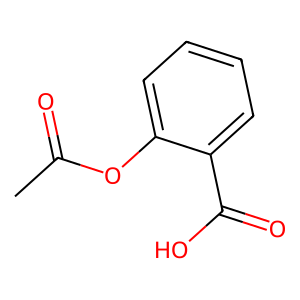
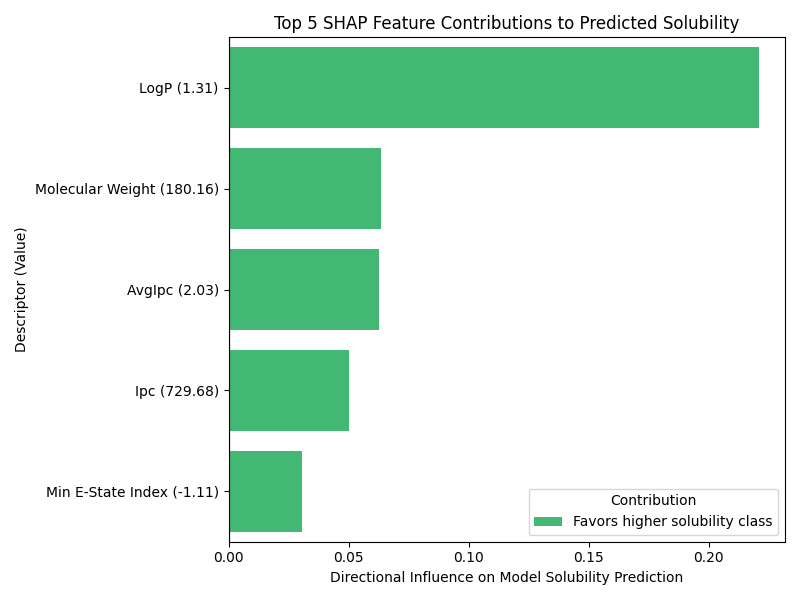

In [66]:
# provide input smiles and generate report
smiles = 'CC(=O)OC1=CC=CC=C1C(O)=O' # Aspirin

generate_html_report(smiles)